In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')
from enrich import enrich_listings

df = enrich_listings()

key_vars = ['price_clean', 'accommodates', 'bedrooms', 'beds', 
            'review_scores_rating', 'availability_365', 
            'number_of_reviews', 'occupancy_rate_calculated']

print(df[key_vars].describe())

Loaded listings: 10480 rows, 79 columns
Price cleaned. Outliers flagged: 7

Date parsing check:
   host_since host_since_parsed
0  2010-03-23        2010-03-23
1  2010-05-13        2010-05-13
2  2010-05-13        2010-05-13
3  2010-08-08        2010-08-08
4  2010-09-01        2010-09-01

Unparseable dates per column:
  last_scraped: 0 unparseable (out of 10480 non-null originals)
  first_review: 1097 unparseable (out of 9383 non-null originals)
  last_review: 1097 unparseable (out of 9383 non-null originals)
  host_since: 3 unparseable (out of 10477 non-null originals)

Property type grouping:
property_type_grouped
Entire place      8214
Private room      1371
Hotel room         418
Houseboat/Boat     392
Other               30
Shared room         29
Room in other       26
Name: count, dtype: int64

Columns after dropping unreliable ones: 85
Missing flags: beds=4576, bathrooms=4548, price=4606

Coordinate precision after standardization:
latitude
5    9349
4    1019
3     105
2       7

In [2]:
print(df[key_vars].describe().to_string())

        price_clean  accommodates      bedrooms         beds  review_scores_rating  availability_365  number_of_reviews  occupancy_rate_calculated
count   5874.000000  10480.000000  10174.000000  5904.000000           9383.000000      10480.000000       10480.000000               10480.000000
mean     336.785155      2.920515      1.554158     1.793022              4.844096         93.999809          47.813359                   0.742322
std     1985.661882      1.276192      0.886438     1.599438              0.257871        122.276158         131.507440                   0.334996
min       35.000000      1.000000      0.000000     0.000000              1.000000          0.000000           0.000000                   0.000000
25%      161.000000      2.000000      1.000000     1.000000              4.790000          0.000000           3.000000                   0.526027
50%      222.000000      2.000000      1.000000     1.000000              4.920000         20.000000          10.00000

C:\Users\HIMAYA\AppData\Local\Temp\ipykernel_12248\1710244257.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


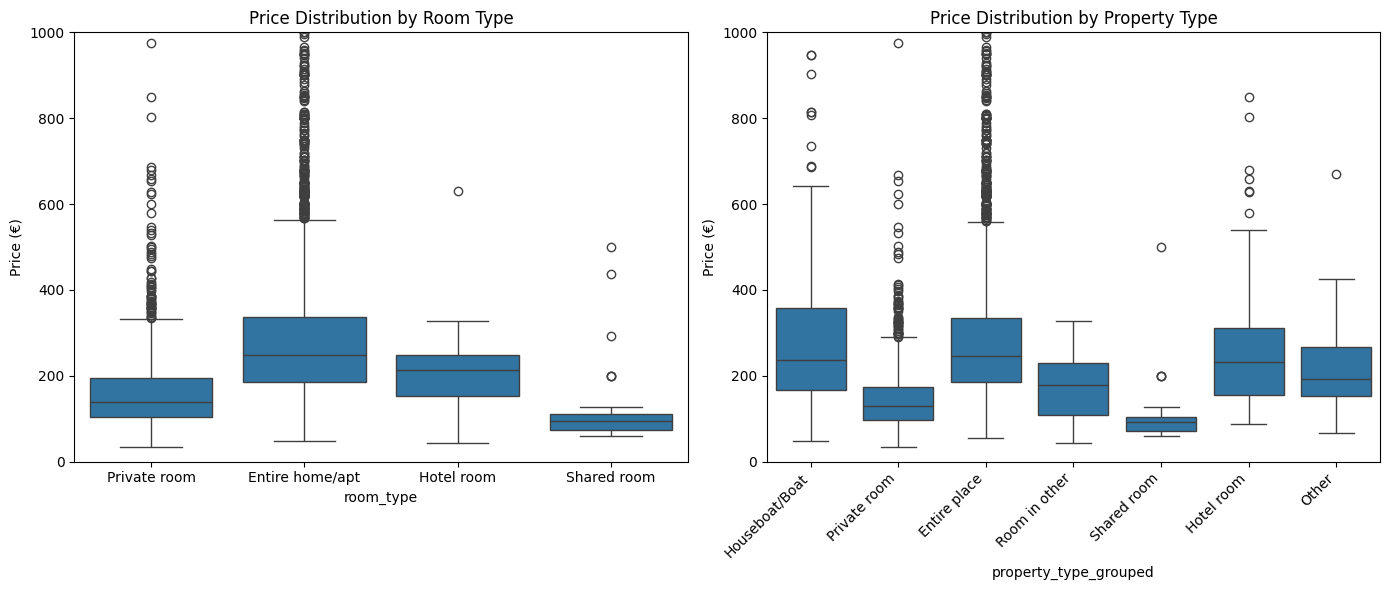

In [3]:
# Filter out outliers and nulls for cleaner visualization
df_price = df[(df['price_outlier_flag'] == False) & (df['price_clean'].notna())]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_price, x='room_type', y='price_clean', ax=axes[0])
axes[0].set_title('Price Distribution by Room Type')
axes[0].set_ylabel('Price (€)')
axes[0].set_ylim(0, 1000)  # zoom in, since a few high values would compress the view

sns.boxplot(data=df_price, x='property_type_grouped', y='price_clean', ax=axes[1])
axes[1].set_title('Price Distribution by Property Type')
axes[1].set_ylabel('Price (€)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../reports/price_by_type.png', dpi=150)
plt.show()

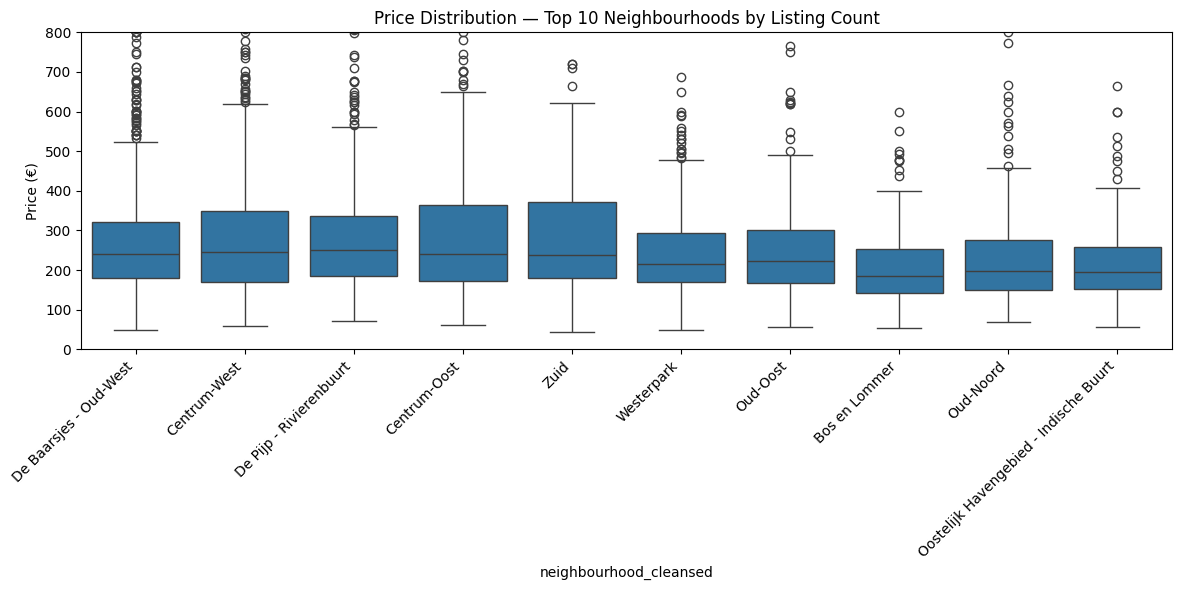

In [4]:
top_neighbourhoods = df_price['neighbourhood_cleansed'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_price[df_price['neighbourhood_cleansed'].isin(top_neighbourhoods)], 
            x='neighbourhood_cleansed', y='price_clean', order=top_neighbourhoods)
plt.title('Price Distribution — Top 10 Neighbourhoods by Listing Count')
plt.ylabel('Price (€)')
plt.ylim(0, 800)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/price_by_neighbourhood.png', dpi=150)
plt.show()

In [5]:
host_listing_counts = df.groupby('host_id').size().sort_values(ascending=False)

print(host_listing_counts.describe())
print()
print("Top 10 hosts by listing count:")
print(host_listing_counts.head(10))

count    9201.000000
mean        1.139007
std         0.896200
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        35.000000
dtype: float64

Top 10 hosts by listing count:
host_id
39110511     35
203731852    23
364305280    23
198405490    18
14574533     15
143098191    15
488984558    15
237150404    13
241644101    13
408898089    13
dtype: int64


In [6]:
total_listings = host_listing_counts.sum()
host_listing_counts_sorted = host_listing_counts.sort_values(ascending=False)
cumulative_pct = host_listing_counts_sorted.cumsum() / total_listings * 100

# What % of hosts account for 50% of listings?
hosts_for_50pct = (cumulative_pct <= 50).sum()
print(f"Number of hosts needed to reach 50% of all listings: {hosts_for_50pct}")
print(f"As a percentage of all hosts: {hosts_for_50pct / len(host_listing_counts) * 100:.2f}%")

# What % of listings are held by hosts with only 1 listing?
single_listing_hosts = (host_listing_counts == 1).sum()
print(f"\nHosts with exactly 1 listing: {single_listing_hosts} ({single_listing_hosts/len(host_listing_counts)*100:.1f}% of all hosts)")
print(f"Listings controlled by single-listing hosts: {single_listing_hosts} ({single_listing_hosts/total_listings*100:.1f}% of all listings)")

Number of hosts needed to reach 50% of all listings: 3961
As a percentage of all hosts: 43.05%

Hosts with exactly 1 listing: 8623 (93.7% of all hosts)
Listings controlled by single-listing hosts: 8623 (82.3% of all listings)


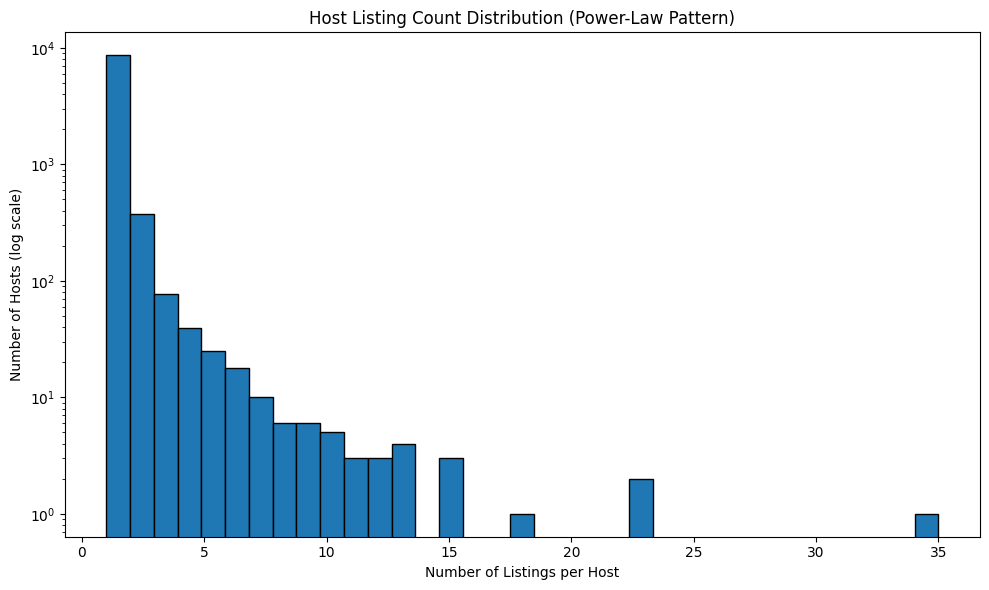

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(host_listing_counts, bins=35, edgecolor='black')
plt.yscale('log')
plt.xlabel('Number of Listings per Host')
plt.ylabel('Number of Hosts (log scale)')
plt.title('Host Listing Count Distribution (Power-Law Pattern)')
plt.tight_layout()
plt.savefig('../reports/host_listing_power_law.png', dpi=150)
plt.show()

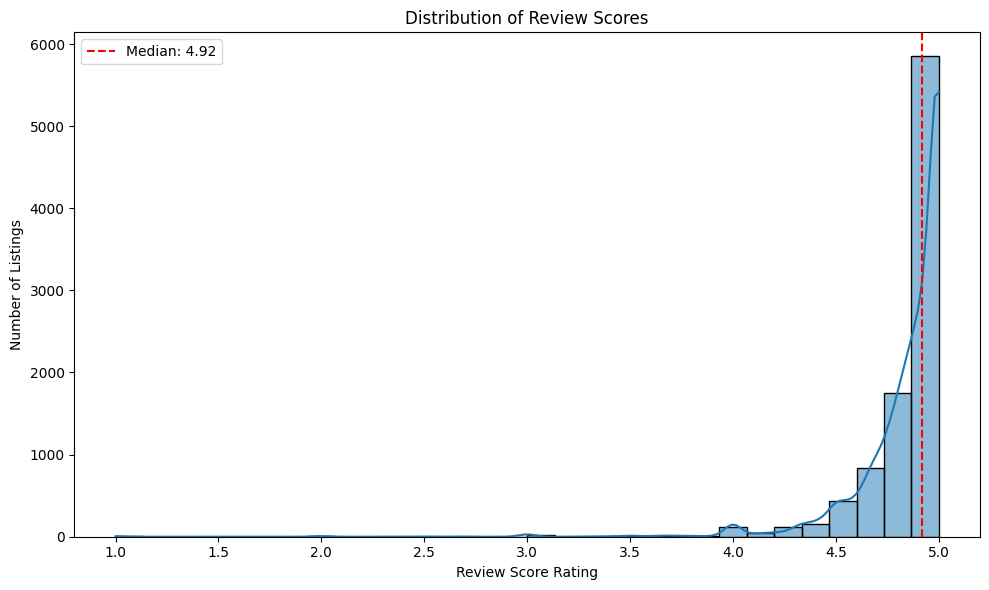

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['review_scores_rating'].dropna(), bins=30, kde=True)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score Rating')
plt.ylabel('Number of Listings')
plt.axvline(df['review_scores_rating'].median(), color='red', linestyle='--', label=f"Median: {df['review_scores_rating'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('../reports/review_score_distribution.png', dpi=150)
plt.show()

In [9]:
from ingest import load_calendar

df_calendar = load_calendar()
df_calendar['date_parsed'] = pd.to_datetime(df_calendar['date'])
df_calendar['month'] = df_calendar['date_parsed'].dt.month

monthly_availability = df_calendar.groupby('month')['available'].apply(
    lambda x: (x == 't').sum() / len(x) * 100
).reset_index(name='pct_available')

print(monthly_availability)

Loaded calendar: 3825200 rows, 7 columns
    month  pct_available
0       1      30.441086
1       2      31.522287
2       3      28.268591
3       4      25.673346
4       5      27.270069
5       6      23.213740
6       7      22.128170
7       8      22.432590
8       9      17.823155
9      10      21.775117
10     11      29.562023
11     12      29.440409


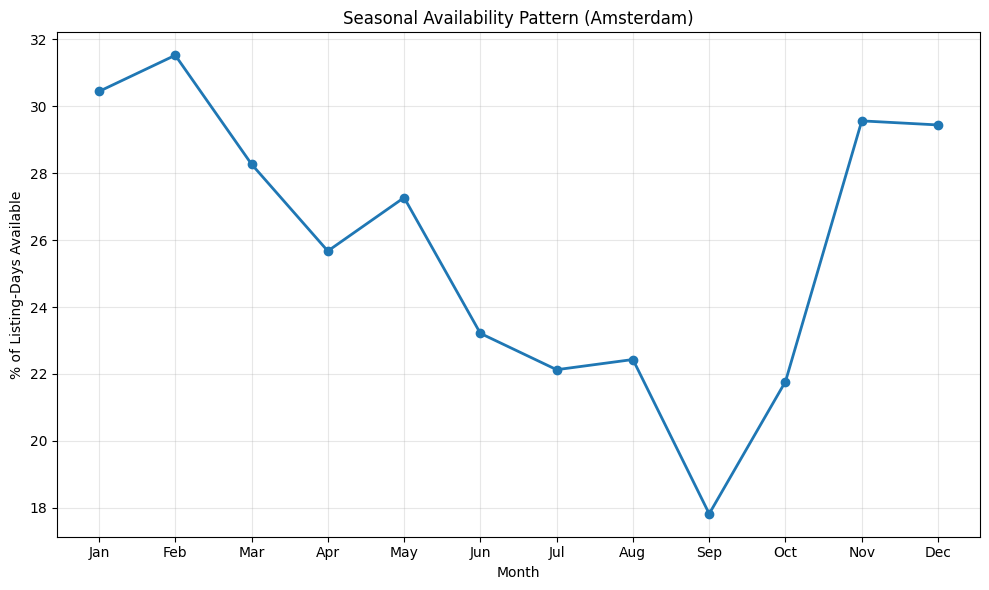

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_availability['month'], monthly_availability['pct_available'], marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('% of Listing-Days Available')
plt.title('Seasonal Availability Pattern (Amsterdam)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/seasonal_availability.png', dpi=150)
plt.show()

In [11]:
pip install folium


   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import folium
import json

with open('../data/raw/neighbourhoods.geojson') as f:
    geo = json.load(f)

# Neighbourhood listing counts (already computed in enrichment)
neighbourhood_counts = df.groupby('neighbourhood_cleansed').size().reset_index(name='listing_count')

m = folium.Map(location=[52.3676, 4.9041], zoom_start=12, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=geo,
    data=neighbourhood_counts,
    columns=['neighbourhood_cleansed', 'listing_count'],
    key_on='feature.properties.neighbourhood',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Number of Listings'
).add_to(m)

m.save('../reports/listing_density_map.html')
m

In [15]:
from math import radians, sin, cos, sqrt, atan2

CENTER_LAT, CENTER_LON = 52.3731, 4.8922  # Dam Square, central Amsterdam

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

df['distance_from_center_km'] = df.apply(
    lambda row: haversine_distance(CENTER_LAT, CENTER_LON, row['latitude'], row['longitude']), axis=1
)

print(df[['distance_from_center_km', 'price_clean']].corr())

                         distance_from_center_km  price_clean
distance_from_center_km                 1.000000     0.022148
price_clean                             0.022148     1.000000


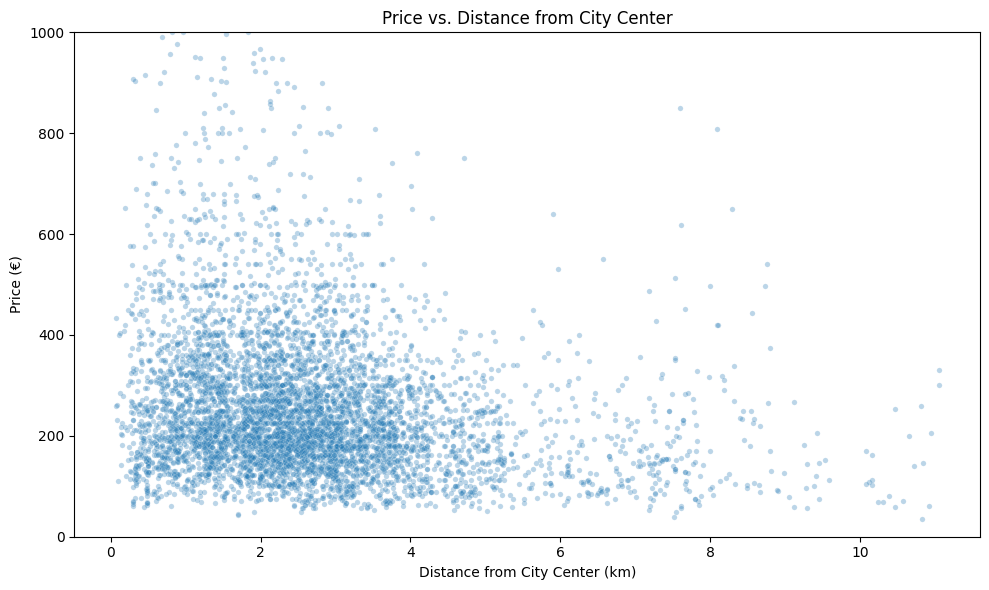

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['price_outlier_flag']==False], 
                 x='distance_from_center_km', y='price_clean', alpha=0.3, s=15)
plt.ylim(0, 1000)
plt.xlabel('Distance from City Center (km)')
plt.ylabel('Price (€)')
plt.title('Price vs. Distance from City Center')
plt.tight_layout()
plt.savefig('../reports/price_vs_distance.png', dpi=150)
plt.show()

In [17]:
neighbourhood_ratings = df.groupby('neighbourhood_cleansed')['review_scores_rating'].mean().reset_index()

m2 = folium.Map(location=[52.3676, 4.9041], zoom_start=12, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=geo,
    data=neighbourhood_ratings,
    columns=['neighbourhood_cleansed', 'review_scores_rating'],
    key_on='feature.properties.neighbourhood',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Average Review Score',
    bins=6
).add_to(m2)

m2.save('../reports/review_score_map.html')
m2

In [18]:
neighbourhood_ratings_full = df.groupby('neighbourhood_cleansed').agg(
    avg_rating=('review_scores_rating', 'mean'),
    listing_count=('id', 'count'),
    rated_count=('review_scores_rating', 'count')
).sort_values('avg_rating')

print(neighbourhood_ratings_full.head(10))

                         avg_rating  listing_count  rated_count
neighbourhood_cleansed                                         
Bijlmer-Centrum            4.638689             66           61
Gaasperdam - Driemond      4.711930             60           57
Geuzenveld - Slotermeer    4.777258            139          124
Bijlmer-Oost               4.785806             38           31
Centrum-West               4.802824           1207         1105
Centrum-Oost               4.809169            923          830
Buitenveldert - Zuidas     4.819495            125           99
Oud-Noord                  4.828512            485          430
Bos en Lommer              4.839556            547          496
Oud-Oost                   4.847435            654          581


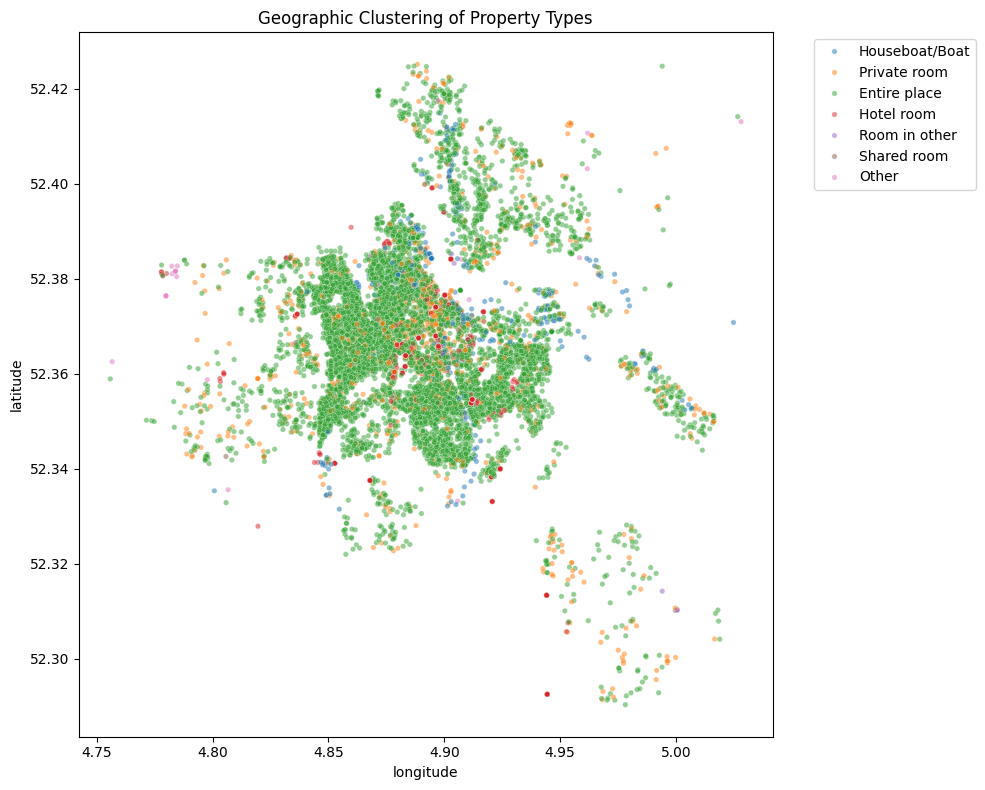

In [19]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='property_type_grouped', 
                 alpha=0.5, s=15, palette='tab10')
plt.title('Geographic Clustering of Property Types')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/property_type_clustering.png', dpi=150)
plt.show()

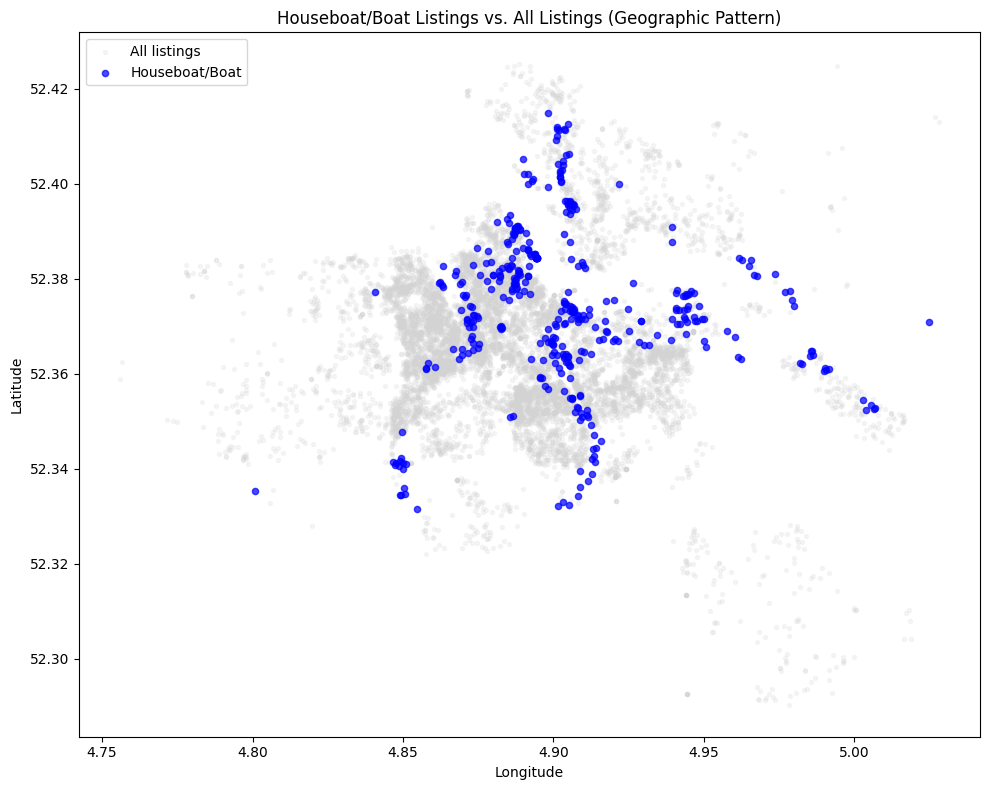

In [20]:
plt.figure(figsize=(10, 8))

# Plot all listings as a faint background for context
plt.scatter(df['longitude'], df['latitude'], c='lightgrey', alpha=0.2, s=8, label='All listings')

# Highlight houseboats specifically
houseboats = df[df['property_type_grouped'] == 'Houseboat/Boat']
plt.scatter(houseboats['longitude'], houseboats['latitude'], c='blue', alpha=0.7, s=20, label='Houseboat/Boat')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Houseboat/Boat Listings vs. All Listings (Geographic Pattern)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/houseboat_clustering.png', dpi=150)
plt.show()